# Load data and train/test split

Everyone uses this. Run these cells first.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
)
import matplotlib.pyplot as plt

df = pd.read_parquet("combined_preprocessed_weather.parquet")
print(df.shape)


(6898737, 26)


In [2]:
df.head()

,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,DEP_DELAY,DEP_DEL15,CRS_ELAPSED_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,...,DEP_HOUR,PREV_FLIGHT_DELAY,HAS_PREV_FLIGHT,WX_TEMP,WX_RHUM,WX_PRCP,WX_WSPD,WX_PRES,WX_CLDC,WX_CODE
0,1,1,3,G4,-5.0,0.0,199.0,1334.0,NaN,NaN,...,10,0.0,0,21.1,90,0.0,7.6,1016.0,4,3
1,1,1,3,G4,-3.0,0.0,223.0,1334.0,NaN,NaN,...,14,-32.0,1,0.0,0,0.0,0.0,0.0,0,0
2,1,2,4,G4,-3.0,0.0,148.0,865.0,NaN,NaN,...,6,0.0,0,17.8,84,0.0,9.4,1020.0,0,2
3,1,2,4,G4,-9.0,0.0,147.0,865.0,NaN,NaN,...,9,-21.0,1,0.0,0,0.0,0.0,0.0,0,0
4,1,2,4,G4,-4.0,0.0,120.0,643.0,NaN,NaN,...,12,-21.0,1,16.7,75,0.0,11.2,1021.5,4,3


In [3]:
# Drop leakage columns (only known AFTER the flight — kept in preprocessed for EDA only)
postprocessing_cols = [
    "DEP_DELAY",
    "DEP_DEL15",
    "CARRIER_DELAY",
    "WEATHER_DELAY",
    "NAS_DELAY",
    "SECURITY_DELAY",
    "LATE_AIRCRAFT_DELAY",
]

X = df.drop(columns=[c for c in postprocessing_cols + ["DELAY_CLASS"] if c in df.columns])
X["DEP_HOUR"] = X["DEP_HOUR"].replace(24, 0)
y = df["DELAY_CLASS"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("Class distribution — train:")
print(y_train.value_counts(normalize=True).sort_index())
print(y_test.value_counts(normalize=True).sort_index())


Train: (5518989, 18), Test: (1379748, 18)
Class distribution — train:
0    0.782692
1    0.071485
2    0.065401
3    0.047472
4    0.032951
Name: DELAY_CLASS, dtype: float64
0    0.782692
1    0.071485
2    0.065401
3    0.047472
4    0.032950
Name: DELAY_CLASS, dtype: float64


### Data Scaling + One Hot Encoding run THIS

In [4]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


numeric_features = X_train.select_dtypes(include=["int8", "int16", "int32", "int64", "float16", "float32", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ]
)

X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)
print(f"Encoded shapes — train: {X_train_preprocessed.shape}, test: {X_test_preprocessed.shape}")


Encoded shapes — train: (5518989, 132), test: (1379748, 132)


### Near Miss resampling. DONT run this. Use the parquet to access the reduce training X and y sets

In [5]:
# # Reference only — markdown above says "DONT run this". Use undersampled_data.parquet instead.
# # Set GENERATE_UNDERSAMPLE = True to regenerate (slow, requires `pip install imbalanced-learn`).
# GENERATE_UNDERSAMPLE = False
# if GENERATE_UNDERSAMPLE:
#     from imblearn.under_sampling import NearMiss
#     from collections import Counter
#     nm = NearMiss(version=2, sampling_strategy="not minority", n_neighbors=3)
#     X_res, y_res = nm.fit_resample(X_train_preprocessed, y_train)
#     print(Counter(y_res))


In [6]:
# if GENERATE_UNDERSAMPLE:
#     # Convert sparse matrix to dense array, then to DataFrame with proper column names
#     import scipy.sparse
#     arr = X_res.toarray() if scipy.sparse.issparse(X_res) else X_res
#     df_res = pd.DataFrame(arr, columns=preprocessor.get_feature_names_out())
#     df_res["DELAY_CLASS"] = y_res
#     df_res.to_parquet("undersampled_data.parquet", index=False, compression="zstd")


# Helper function so everyone reports the same metrics.

In [7]:
CLASS_NAMES = ['No Delay', '15-29 min', '30-59 min', '1-2 hr', '2+ hr']

def evaluate(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    print(f"--- {name} ---")
    print(f"Accuracy:      {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision (w): {precision_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"Recall (w):    {recall_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"F1 (w):        {f1_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
    print(f"F1 (macro):    {f1_score(y_test, y_pred, average='macro', zero_division=0):.4f}  ← primary metric for imbalanced multiclass")
    print(f"Precision (m): {precision_score(y_test, y_pred, average='macro', zero_division=0):.4f}")
    print(f"Recall (m):    {recall_score(y_test, y_pred, average='macro', zero_division=0):.4f}")
    print(f"AUC-ROC:       {roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted'):.4f}")
    print()
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(cm, cmap="Blues")
    for i in range(len(CLASS_NAMES)):
        for j in range(len(CLASS_NAMES)):
            ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=10)
    ax.set_xticks(range(len(CLASS_NAMES)))
    ax.set_yticks(range(len(CLASS_NAMES)))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"{name} — Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 (macro)": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "Precision (macro)": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1 (weighted)": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "AUC-ROC": roc_auc_score(y_test, y_prob, multi_class="ovr", average="weighted"),
    }


In [8]:
results = []


**most difficult task -- what features should we use??**

**what features we should drop?? one by one**

**and then, One-hot encoding so that we can add the destination in there**

---
# Aryan — Naive Model

--- Naive Model ---
Accuracy:      0.2312
Precision (w): 0.6479
Recall (w):    0.2312
F1 (w):        0.3120
F1 (macro):    0.1427  ← primary metric for imbalanced multiclass
Precision (m): 0.2073
Recall (m):    0.2044
AUC-ROC:       0.5159

              precision    recall  f1-score   support

    No Delay       0.81      0.24      0.37   1079918
   15-29 min       0.07      0.16      0.10     98631
   30-59 min       0.08      0.23      0.12     90237
      1-2 hr       0.04      0.15      0.07     65499
       2+ hr       0.03      0.24      0.06     45463

    accuracy                           0.23   1379748
   macro avg       0.21      0.20      0.14   1379748
weighted avg       0.65      0.23      0.31   1379748



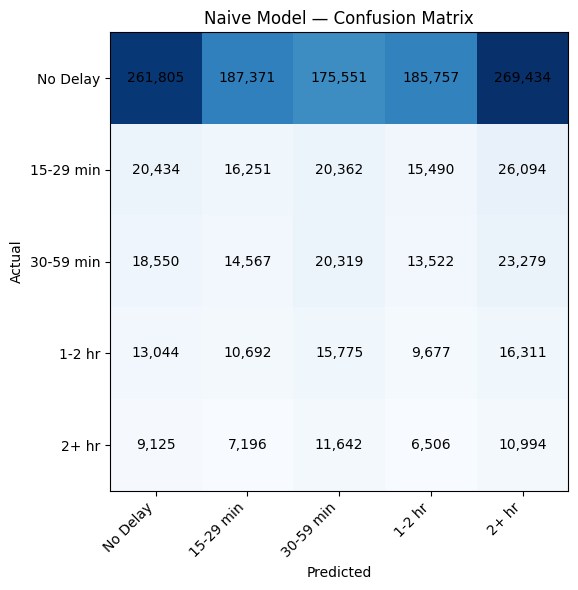

In [9]:
class SimpleNaiveModel:
    def predict(self, X):
        feature = X[:, 0]
        pred = np.zeros(X.shape[0], dtype=int)
        pred[feature >= 0.8] = 4
        pred[(feature >= 0.6) & (feature < 0.8)] = 3
        pred[(feature >= 0.4) & (feature < 0.6)] = 2
        pred[(feature >= 0.2) & (feature < 0.4)] = 1
        return pred
    
    def predict_proba(self, X):
        pred = self.predict(X)
        proba = np.zeros((X.shape[0], 5))
        # Set predicted class to 1.0, others to 0.0
        proba[np.arange(X.shape[0]), pred] = 1.0
        return proba

naive_model = SimpleNaiveModel()
results.append(evaluate('Naive Model', naive_model, X_test_preprocessed, y_test))

---
# Sam — Logistic Regression

/Users/spartan4life/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


--- Logistic Regression ---
Accuracy:      0.5830
Precision (w): 0.7403
Recall (w):    0.5830
F1 (w):        0.6412
F1 (macro):    0.3087  ← primary metric for imbalanced multiclass
Precision (m): 0.3061
Recall (m):    0.3666
AUC-ROC:       0.7714

              precision    recall  f1-score   support

    No Delay       0.90      0.67      0.77   1079918
   15-29 min       0.12      0.38      0.19     98631
   30-59 min       0.16      0.15      0.16     90237
      1-2 hr       0.18      0.22      0.19     65499
       2+ hr       0.17      0.42      0.24     45463

    accuracy                           0.58   1379748
   macro avg       0.31      0.37      0.31   1379748
weighted avg       0.74      0.58      0.64   1379748



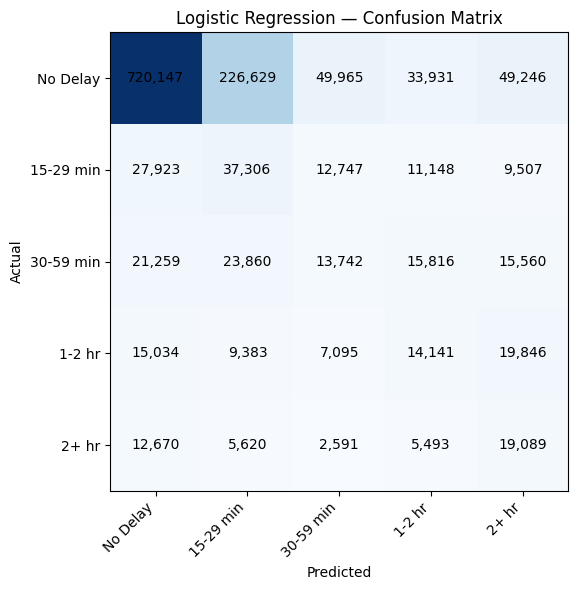

In [10]:
from sklearn.linear_model import LogisticRegression
import numpy as np

# Shared 500k sample — same index used by LR, RF, XGBoost for fair comparison
rng = np.random.RandomState(42)
SAMPLE_IDX = rng.choice(X_train_preprocessed.shape[0], 500_000, replace=False)
X_train_500k = X_train_preprocessed[SAMPLE_IDX]
y_train_500k = y_train.iloc[SAMPLE_IDX]

lr_model = LogisticRegression(
    solver="saga",
    max_iter=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
lr_model.fit(X_train_500k, y_train_500k)

results.append(evaluate('Logistic Regression', lr_model, X_test_preprocessed, y_test))


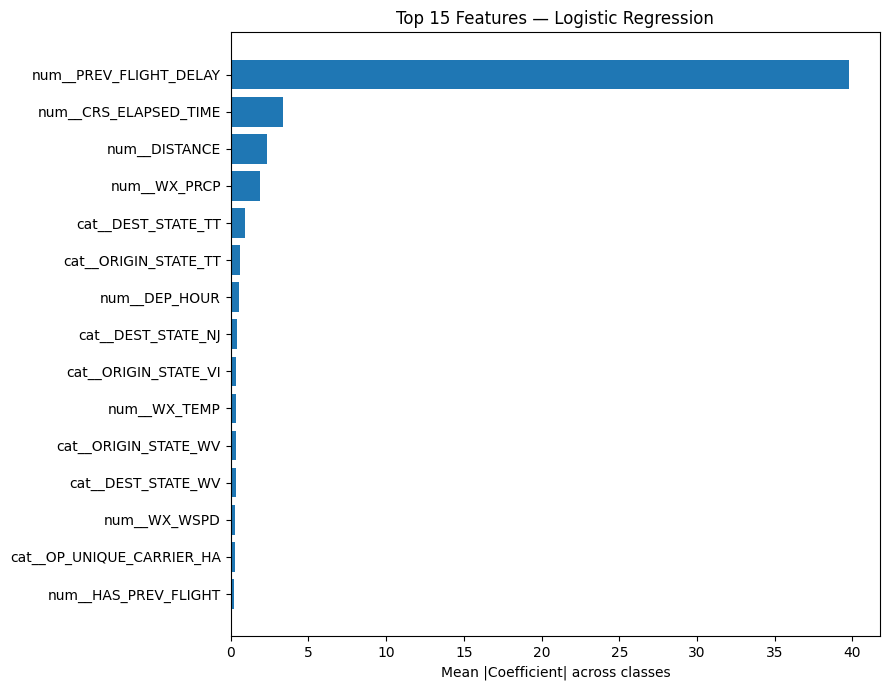

In [11]:
# Feature importance: mean absolute coefficient across classes
feature_names = preprocessor.get_feature_names_out()
mean_abs_coef = np.abs(lr_model.coef_).mean(axis=0)

coef_df = pd.DataFrame({
    "feature": feature_names,
    "importance": mean_abs_coef,
}).nlargest(15, "importance").sort_values("importance")

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(coef_df["feature"], coef_df["importance"], color="#1f77b4")
ax.set_xlabel("Mean |Coefficient| across classes")
ax.set_title("Top 15 Features — Logistic Regression")
plt.tight_layout()
plt.show()


---
# Wahid — Random Forest

--- Random Forest ---
Accuracy:      0.7468
Precision (w): 0.7752
Recall (w):    0.7468
F1 (w):        0.7581
F1 (macro):    0.4643  ← primary metric for imbalanced multiclass
Precision (m): 0.4845
Recall (m):    0.4610
AUC-ROC:       0.7880

              precision    recall  f1-score   support

    No Delay       0.89      0.85      0.87   1079918
   15-29 min       0.22      0.40      0.28     98631
   30-59 min       0.38      0.34      0.36     90237
      1-2 hr       0.49      0.37      0.42     65499
       2+ hr       0.45      0.35      0.39     45463

    accuracy                           0.75   1379748
   macro avg       0.48      0.46      0.46   1379748
weighted avg       0.78      0.75      0.76   1379748



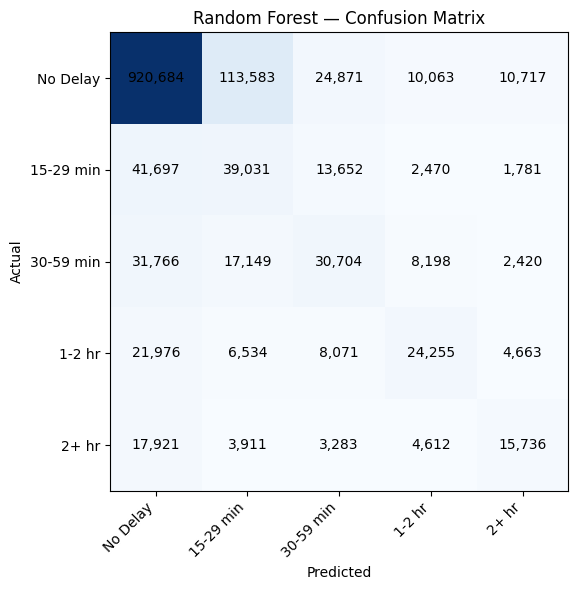

In [12]:
from sklearn.ensemble import RandomForestClassifier

# Uses the same 500k sample defined in the Logistic Regression cell
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train_500k, y_train_500k)

results.append(evaluate('Random Forest', rf_model, X_test_preprocessed, y_test))


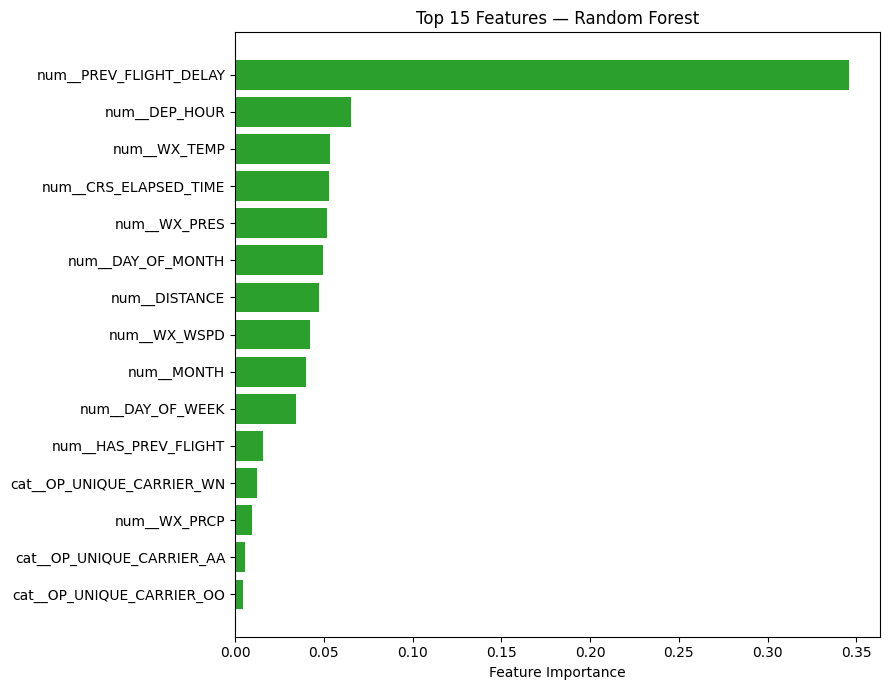

In [13]:
feature_names = preprocessor.get_feature_names_out()
imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_,
}).nlargest(15, "importance").sort_values("importance")

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(imp_df["feature"], imp_df["importance"], color="#2ca02c")
ax.set_xlabel("Feature Importance")
ax.set_title("Top 15 Features — Random Forest")
plt.tight_layout()
plt.show()


---
# Aryan — XGBoost

--- XGBoost ---
Accuracy:      0.7031
Precision (w): 0.7806
Recall (w):    0.7031
F1 (w):        0.7331
F1 (macro):    0.4384  ← primary metric for imbalanced multiclass
Precision (m): 0.4354
Recall (m):    0.4831
AUC-ROC:       0.8118

              precision    recall  f1-score   support

    No Delay       0.91      0.79      0.84   1079918
   15-29 min       0.21      0.47      0.29     98631
   30-59 min       0.44      0.34      0.38     90237
      1-2 hr       0.41      0.38      0.39     65499
       2+ hr       0.21      0.45      0.28     45463

    accuracy                           0.70   1379748
   macro avg       0.44      0.48      0.44   1379748
weighted avg       0.78      0.70      0.73   1379748



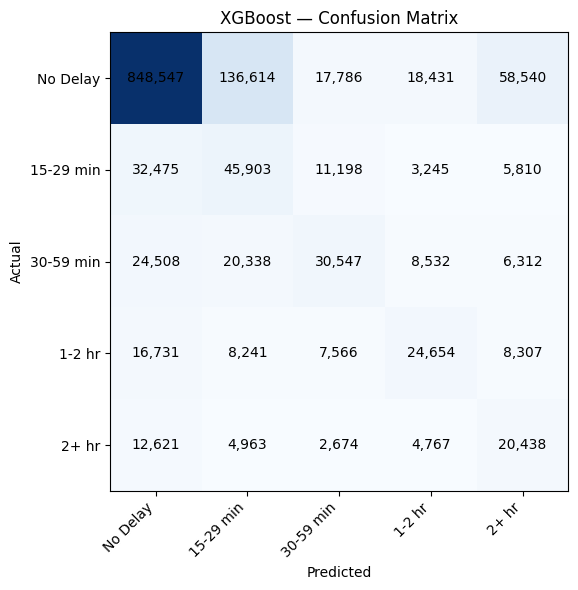

In [14]:
import xgboost as xgb

# Uses the same 500k sample defined in the Logistic Regression cell
X_train_xgb = X_train_500k
X_test_xgb  = X_test_preprocessed
y_train_xgb = y_train_500k.values

# Inverse class frequency weights for imbalance
class_counts = np.bincount(y_train_xgb)
class_weights = len(y_train_xgb) / (len(class_counts) * class_counts)
sample_weights = class_weights[y_train_xgb]

xgb_model = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=5,
    max_depth=5,
    learning_rate=0.2,
    n_estimators=100,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
)
xgb_model.fit(X_train_xgb, y_train_xgb, sample_weight=sample_weights, verbose=False)

results.append(evaluate('XGBoost', xgb_model, X_test_xgb, y_test))

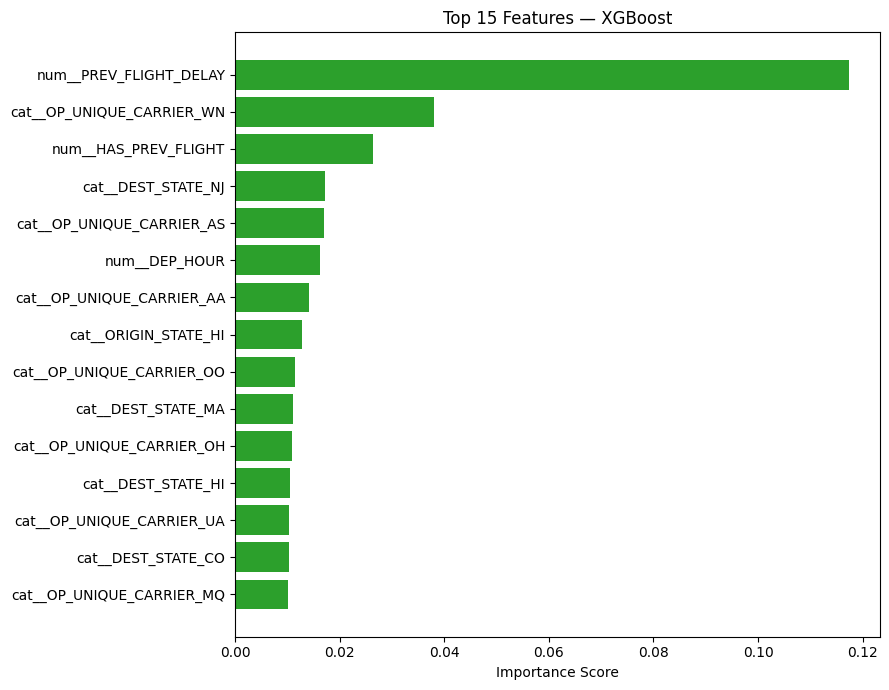

In [15]:
# XGBoost feature importance — use encoded feature names to match the model
importances = xgb_model.feature_importances_
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances,
}).nlargest(15, "importance").sort_values("importance")

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(importance_df["feature"], importance_df["importance"], color="#2ca02c")
ax.set_xlabel("Importance Score")
ax.set_title("Top 15 Features — XGBoost")
plt.tight_layout()
plt.show()


---
# Dennis — Naive Bayes

## Naive Bayes

In [16]:
from sklearn.preprocessing import OrdinalEncoder

def pipeline(data, encoder = None):

    cat_cols_idx = []
    for col_idx, col in enumerate(data.columns):
        if col != "DISTANCE":
            cat_cols_idx.append(col_idx)

    if encoder is None:
        encoder = OrdinalEncoder(dtype = int)
        data.iloc[:, cat_cols_idx] = encoder.fit_transform(data.iloc[:, cat_cols_idx])
    else:
        data.iloc[:, cat_cols_idx] = encoder.transform(data.iloc[:, cat_cols_idx])

    data = data.apply(pd.to_numeric)

    return data, encoder


In [17]:
# Load the same preprocessed file (no separate no-leakage parquet exists)
df_nb = pd.read_parquet("combined_preprocessed_weather.parquet")

leak_cols = [
    "DEP_DELAY",
    "ARR_DELAY",
    "DEP_DEL15",
    "CARRIER_DELAY",
    "WEATHER_DELAY",
    "NAS_DELAY",
    "SECURITY_DELAY",
    "LATE_AIRCRAFT_DELAY",
    "DIVERTED",
    "DEST_AIRPORT_SEQ_ID",
]
X_nb = df_nb.drop(columns=[c for c in leak_cols + ["DELAY_CLASS"] if c in df_nb.columns])
X_nb["DEP_HOUR"] = X_nb["DEP_HOUR"].replace(24, 0)

y_nb = df_nb["DELAY_CLASS"]

X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X_nb,
    y_nb,
    test_size=0.2,
    random_state=42,
    stratify=y_nb,
)


In [18]:
from sklearn.preprocessing import OrdinalEncoder

# MixedNB needs truly continuous cols treated as numeric, not categorical
NUMERIC_COLS = {"DISTANCE", "CRS_ELAPSED_TIME", "PREV_FLIGHT_DELAY"}

encoder = OrdinalEncoder(dtype=int, handle_unknown="use_encoded_value", unknown_value=-1)
cat_cols = [col for col in X_nb.columns if col not in NUMERIC_COLS]
encoder.fit(X_nb[cat_cols])

# Balanced 500k sample (100k per class) — matches sample size used by LR/RF/XGBoost
PER_CLASS = 100_000
min_count = min(y_train_nb.value_counts().min(), PER_CLASS)
X_train_bal = (
    X_train_nb.groupby(y_train_nb, group_keys=False)
    .apply(lambda x: x.sample(min_count, random_state=42))
    .reset_index(drop=True)
)
y_train_bal = (
    y_train_nb.groupby(y_train_nb, group_keys=False)
    .apply(lambda x: x.sample(min_count, random_state=42))
    .reset_index(drop=True)
)

def nb_pipeline(data, encoder):
    data = data.copy()
    cat_cols_idx = [i for i, col in enumerate(data.columns) if col not in NUMERIC_COLS]
    data.iloc[:, cat_cols_idx] = encoder.transform(data.iloc[:, cat_cols_idx])
    return data.apply(pd.to_numeric)

X_train_bal = nb_pipeline(X_train_bal, encoder)
X_test_nb   = nb_pipeline(X_test_nb, encoder)
print(f"NB train size: {len(X_train_bal):,} ({min_count:,} per class)")


/var/folders/wq/cbr397vs4lg_5jhclv7yd5r40000gn/T/ipykernel_24641/2138484206.py:27: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  data.iloc[:, cat_cols_idx] = encoder.transform(data.iloc[:, cat_cols_idx])
/var/folders/wq/cbr397vs4lg_5jhclv7yd5r40000gn/T/ipykernel_24641/2138484206.py:27: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  data.iloc[:, cat_cols_idx] = encoder.transform(data.iloc[:, cat_cols_idx])


NB train size: 500,000 (100,000 per class)


In [19]:
X_train_bal.head()


,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,CRS_ELAPSED_TIME,DISTANCE,ORIGIN_STATE,DEST_STATE,DEP_HOUR,PREV_FLIGHT_DELAY,HAS_PREV_FLIGHT,WX_TEMP,WX_RHUM,WX_PRCP,WX_WSPD,WX_PRES,WX_CLDC,WX_CODE
0,3,0,1,12,75.0,293.0,44,44,17,-3.0,1,332,74,0,83,282,3,3
1,0,2,4,11,198.0,1492.0,5,33,18,-11.0,1,110,84,0,33,441,6,3
2,7,29,5,5,127.0,855.0,3,15,10,-15.0,1,127,0,0,0,0,0,0
3,6,18,5,10,208.0,1081.0,13,5,8,-12.0,1,365,73,0,0,371,8,3
4,11,5,5,10,94.0,404.0,44,15,13,-27.0,1,186,91,0,47,351,8,5


In [25]:
from mixed_naive_bayes import MixedNB

cat_cols_idx = [i for i, col in enumerate(X_train_bal.columns) if col not in NUMERIC_COLS]

# Calculate max categories from the FULL original dataset (before sampling)
# to ensure test data categories are handled properly
X_full_encoded = nb_pipeline(X_nb, encoder)
max_categories = np.array([int(X_full_encoded.iloc[:, idx].max()) + 1 for idx in cat_cols_idx])

nb_clf = MixedNB(categorical_features=cat_cols_idx, max_categories=max_categories)
nb_clf.fit(X_train_bal, y_train_bal)


/var/folders/wq/cbr397vs4lg_5jhclv7yd5r40000gn/T/ipykernel_24641/2138484206.py:27: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  data.iloc[:, cat_cols_idx] = encoder.transform(data.iloc[:, cat_cols_idx])


MixedNB(alpha=0.5, var_smoothing=1e-09)

--- Naive Bayes ---
Accuracy:      0.5591
Precision (w): 0.7382
Recall (w):    0.5591
F1 (w):        0.6231
F1 (macro):    0.3248  ← primary metric for imbalanced multiclass
Precision (m): 0.3268
Recall (m):    0.3741
AUC-ROC:       0.7473

              precision    recall  f1-score   support

    No Delay       0.90      0.63      0.74   1079918
   15-29 min       0.11      0.43      0.18     98631
   30-59 min       0.16      0.18      0.17     90237
      1-2 hr       0.22      0.30      0.25     65499
       2+ hr       0.24      0.33      0.28     45463

    accuracy                           0.56   1379748
   macro avg       0.33      0.37      0.32   1379748
weighted avg       0.74      0.56      0.62   1379748



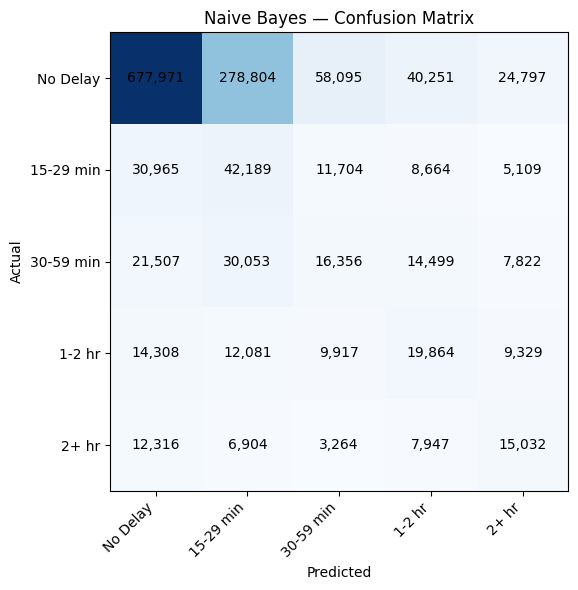

In [26]:
results.append(evaluate(name='Naive Bayes', model=nb_clf, X_test=X_test_nb, y_test=y_test_nb))


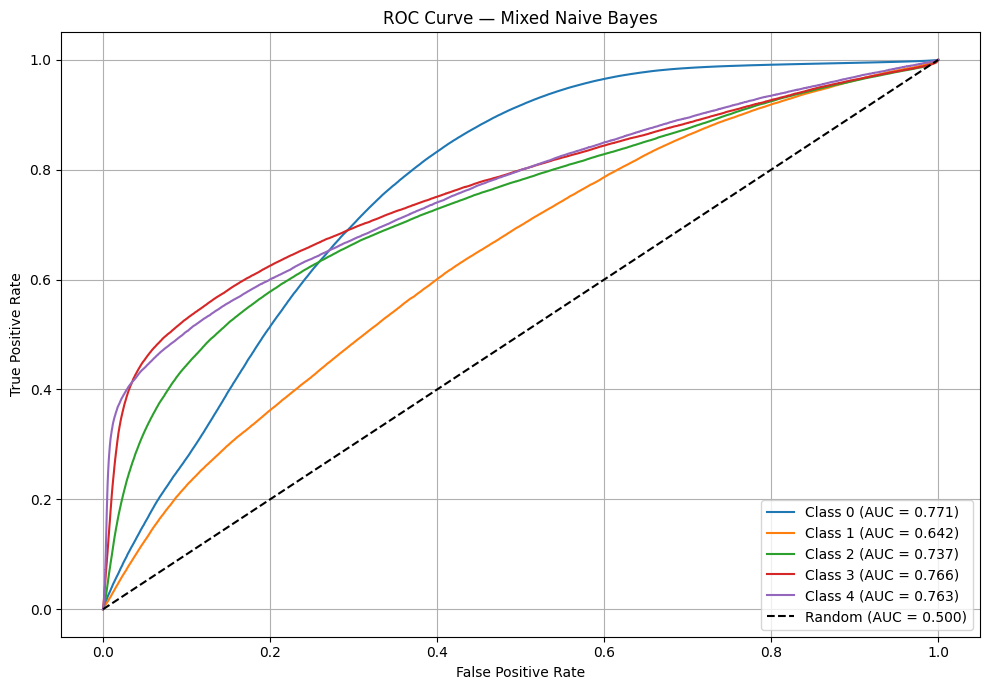

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_proba = nb_clf.predict_proba(X_test_nb)

classes = np.unique(y_test_nb)
y_test_bin = label_binarize(y_test_nb, classes=classes)

plt.figure(figsize=(10, 7))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {cls} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.500)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Mixed Naive Bayes")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


---
# Aryan - RNN
Requires specific version `pip install tensorflow==2.18.0`

In [ ]:
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

# Scale X_train and X_test with StandardScaler
scaler = StandardScaler()
X_train_rnn = scaler.fit_transform(X_train_500k)
X_test_rnn = scaler.transform(X_test_preprocessed)

# Reshape to 3D: (samples, 1, features) — RNN expects 3D input
X_train_rnn = X_train_rnn.reshape(X_train_rnn.shape[0], 1, X_train_rnn.shape[1])
X_test_rnn = X_test_rnn.reshape(X_test_rnn.shape[0], 1, X_test_rnn.shape[1])

print(f"RNN train shape: {X_train_rnn.shape}, test shape: {X_test_rnn.shape}")


RNN train shape: (500000, 1, 132), test shape: (1379748, 1, 132)


In [ ]:
# Build Sequential: SimpleRNN(64) -> Dropout(0.3) -> Dense(32) -> Dense(5, softmax)
rnn_model = Sequential([
    SimpleRNN(64, activation='relu', input_shape=(1, X_train_rnn.shape[2])),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(5, activation='softmax')
])

# Compile with optimizer='adam', loss='sparse_categorical_crossentropy'
rnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Fit with epochs=10, batch_size=1024, validation_split=0.1
rnn_model.fit(
    X_train_rnn,
    y_train_500k.values,
    epochs=30,
    batch_size=1024,
    validation_split=0.1,
    verbose=1
)


NameError: name 'Sequential' is not defined

--- RNN ---
Accuracy:      0.8240
Precision (w): 0.7867
Recall (w):    0.8240
F1 (w):        0.7909
F1 (macro):    0.4719  ← primary metric for imbalanced multiclass
Precision (m): 0.6122
Recall (m):    0.4147
AUC-ROC:       0.8109

              precision    recall  f1-score   support

    No Delay       0.86      0.98      0.91   1079918
   15-29 min       0.46      0.15      0.22     98631
   30-59 min       0.53      0.32      0.40     90237
      1-2 hr       0.59      0.34      0.43     65499
       2+ hr       0.62      0.28      0.39     45463

    accuracy                           0.82   1379748
   macro avg       0.61      0.41      0.47   1379748
weighted avg       0.79      0.82      0.79   1379748



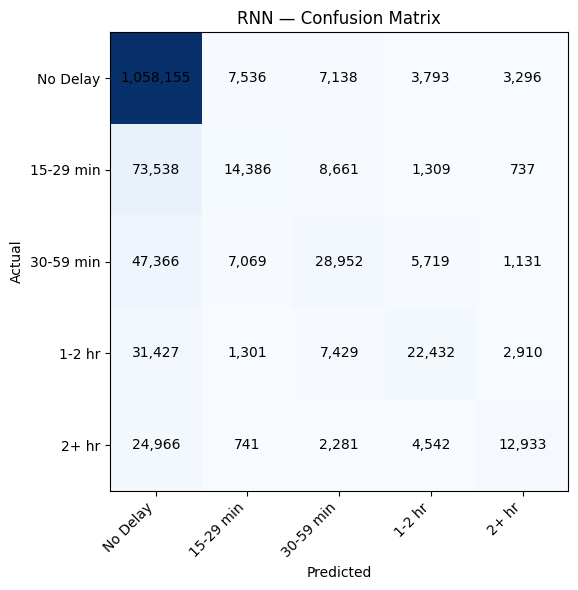

In [ ]:
# Create wrapper to match sklearn interface
class RNNWrapper:
    def __init__(self, model):
        self.model = model

    def predict(self, X):
        probabilities = self.model.predict(X, verbose=0)
        return probabilities.argmax(axis=1)

    def predict_proba(self, X):
        return self.model.predict(X, verbose=0)

# Get probabilities: y_prob = rnn_model.predict(X_test_rnn)  # shape (N, 5)
# Get predictions: y_pred = y_prob.argmax(axis=1)
# Print weighted metrics (accuracy, precision, recall, F1, AUC-ROC with multi_class='ovr')
# Plot confusion matrix (5x5)
# Append results dict to results list
rnn_wrapper = RNNWrapper(rnn_model)
results.append(evaluate('RNN', rnn_wrapper, X_test_rnn, y_test))


---
# Compare all models

In [ ]:
comparison = pd.DataFrame(results).set_index('Model')
comparison.round(4)

,Accuracy,F1 (macro),Precision (macro),Recall (macro),F1 (weighted),AUC-ROC
Model,,,,,,
Logistic Regression,0.5979,0.3164,0.3105,0.3706,0.6518,0.7721
Random Forest,0.7425,0.4656,0.4914,0.4626,0.7564,0.7907
XGBoost,0.7070,0.4410,0.4403,0.4824,0.7358,0.8108
Naive Bayes,0.5931,0.3666,0.3913,0.3964,0.6505,0.7590
RNN,0.8240,0.4719,0.6122,0.4147,0.7909,0.8109


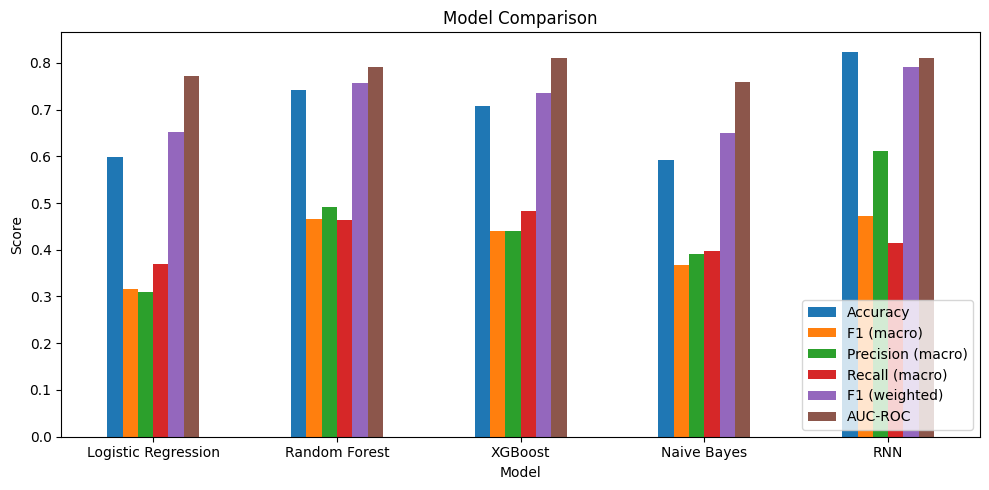

In [ ]:
comparison.plot.bar(figsize=(10, 5), title='Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
pd.read_parquet("combined_preprocessed_weather.parquet")

,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,DEP_DELAY,DEP_DEL15,CRS_ELAPSED_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,...,DEP_HOUR,PREV_FLIGHT_DELAY,HAS_PREV_FLIGHT,WX_TEMP,WX_RHUM,WX_PRCP,WX_WSPD,WX_PRES,WX_CLDC,WX_CODE
0,1,1,3,G4,-5.0,0.0,199.0,1334.0,NaN,NaN,...,10,0.0,0,21.1,90,0.0,7.6,1016.0,4,3
1,1,1,3,G4,-3.0,0.0,223.0,1334.0,NaN,NaN,...,14,-32.0,1,0.0,0,0.0,0.0,0.0,0,0
2,1,2,4,G4,-3.0,0.0,148.0,865.0,NaN,NaN,...,6,0.0,0,17.8,84,0.0,9.4,1020.0,0,2
3,1,2,4,G4,-9.0,0.0,147.0,865.0,NaN,NaN,...,9,-21.0,1,0.0,0,0.0,0.0,0.0,0,0
4,1,2,4,G4,-4.0,0.0,120.0,643.0,NaN,NaN,...,12,-21.0,1,16.7,75,0.0,11.2,1021.5,4,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6898732,12,29,1,B6,31.0,1.0,252.0,1674.0,7.0,0.0,...,20,34.0,1,26.0,65,0.0,13.0,1016.0,2,2
6898733,12,30,2,B6,34.0,1.0,217.0,1237.0,7.0,0.0,...,17,0.0,0,-3.0,41,0.0,39.0,998.0,8,3
6898734,12,30,2,B6,34.0,1.0,171.0,1069.0,12.0,0.0,...,22,17.0,1,16.0,42,0.0,19.0,1017.0,2,2
6898735,12,31,3,B6,-4.0,0.0,190.0,1069.0,NaN,NaN,...,6,0.0,0,-3.0,42,0.0,30.0,1010.0,6,2
